# **Netflix Movie Analysis**

## Overview

Netflix was founded on August 29, 1997, in Scotts Valley, California, by Reed Hastings and Marc Randolph. It began as a **DVD-by-mail service**. Hastings, a computer scientist and mathematician, co-founded the company after being inspired by a hefty late fee from a traditional video rental store. Randolph, a marketing executive, played a pivotal role in shaping Netflix's early user interface and branding.


In 2007, Netflix introduced streaming services, allowing subscribers to watch movies and TV shows instantly online. This strategic shift capitalized on the growing internet bandwidth and changing consumer preferences, propelling Netflix into a leading global streaming platform. The company's national expansion, starting with Canada, and by 2016, it was available in over 190 countries. By 2010, the company began its international expansion, starting with Canada, and by 2016, it was available in over 190 countries. 

As of 2024, Netflix reported a revenue of nearly `$10 billion` in the third quarter, with profits reaching `$2.4 billion`. 
The platform boasts over `283 million` paid memberships across more than 190 countries, offering a vast library of TV series, films, and games in various genres and languages. 

Overall, Netflix's evolution from a DVD rental service to a global streaming giant underscores its adaptability and innovative approach in the entertainment industry.



---

Netflix is known for its work in **data science, AI, and ML**, particularly for **building strong recommendation models and algorithms that understand customer behavior and patterns**. For this project, I am working in a data-driven job role, and I have a dataset of more than 9,000 movies. I solved the following questions to help the company make informed business decisions accordingly.

### Objectives

1. What is the most frequent genre of movies released on Netflix?
2. Which has highest votes in vote avg column?
3. What movie got the highest popularity? what's its genre?
4. What movie got the lowest popularity? what's its genre?
5. Which year has the most filmmed movies?




---

### Importing the libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Reading the dataset using the pandas library

In [53]:
df= pd.read_csv('netflix_movies_dataset.csv', lineterminator='\n')
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


Checking the datatypes of the columns

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


Checking the datatypes of the columns, `Release_Date` is in object format (string). It should be in datetime format because it is a date column. I convert it to datetime format.

In [55]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Release_Date       9827 non-null   datetime64[ns]
 1   Title              9827 non-null   object        
 2   Overview           9827 non-null   object        
 3   Popularity         9827 non-null   float64       
 4   Vote_Count         9827 non-null   int64         
 5   Vote_Average       9827 non-null   float64       
 6   Original_Language  9827 non-null   object        
 7   Genre              9827 non-null   object        
 8   Poster_Url         9827 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 691.1+ KB


Further, the question 5 asks for just the year, so I extract the year from the `Release_Date` column.

In [56]:
df['Release_Year'] = df['Release_Date'].dt.year
df.head(1)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,Release_Year
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...,2021


In [57]:
df["Release_Year"].dtypes

dtype('int32')

Checking the number of rows and columns in the dataset

In [58]:
df.shape

(9827, 10)

There are 9827 movie entries and 10 attributes for each movie in the dataset

Checking for any duplicate entries in the dataset

In [59]:
df.duplicated().sum().item(0)

0

Great! There are no duplicate entries in the dataset.

Checking for any null values in the dataset

In [60]:
df.isnull().sum()

Release_Date         0
Title                0
Overview             0
Popularity           0
Vote_Count           0
Vote_Average         0
Original_Language    0
Genre                0
Poster_Url           0
Release_Year         0
dtype: int64

There are no null values in the dataset. Each column has 9827 entries.

Now, I dropped the unneccessary columns from the dataset which includes `Release_Date`, `Overview`, `Original_Language`, and `Poster_Url`

In [61]:
cols = ['Release_Date', 'Overview', 'Original_Language', 'Poster_Url']
df = df.drop(cols, axis=1)
df.head()

,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_Year
0,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction",2021
1,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller",2022
2,No Exit,2618.087,122,6.3,Thriller,2022
3,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy",2021
4,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War",2021


Getting a quick descriptive statistics summary of the dataset using the `describe()` method.

In [62]:
df.describe()

,Popularity,Vote_Count,Vote_Average,Release_Year
count,9827.000000,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534,2006.203623
std,108.873998,2611.206907,1.129759,15.685554
min,13.354000,0.000000,0.000000,1902.000000
25%,16.128500,146.000000,5.900000,2000.000000
50%,21.199000,444.000000,6.500000,2011.000000
75%,35.191500,1376.000000,7.100000,2017.000000
max,5083.954000,31077.000000,10.000000,2024.000000


Now, I categroized the Vote_Average column into 4 categories: `popular`, `average`, `below average`, and `unpopular`. Categorization makes it easier for auidence to understand the movie's popularity, instead of looking at numeric values.

I used the categorize function to create a new column called `Vote_Average_Categories`. 

In [ ]:
def categorize(df, col, labels):
    edges = [df[col].describe()['min'], df[col].describe()['25%'], 
             df[col].describe()['50%'], df[col].describe()['75%'], 
             df[col].describe()['max']]

    df[col] = pd.cut(df[col], edges, labels=labels, duplicates='drop', include_lowest=True)
    return df

In [ ]:
labels = ['unpopular', 'below average', 'average', 'popular']
categorize(df, 'Vote_Average', labels)
df['Vote_Average'].unique()

['popular', 'below average', 'average', 'unpopular']
Categories (4, object): ['unpopular' < 'below average' < 'average' < 'popular']

In [ ]:
df_new['Vote_Average'].describe()

count          9827
unique            4
top       unpopular
freq           2567
Name: Vote_Average, dtype: object

In [ ]:
df_new['Vote_Average'].value_counts()

Vote_Average
unpopular        2567
popular          2450
average          2412
below average    2398
Name: count, dtype: int64

I have successfully categorized the `Vote_Average` column into 4 categories. Unpopular movies have the highest friequency of 2567 movies, however the recommendation system would not recommend these movies to users.

Now, I splitted `Genre` column using explode method to have each genre in a separate row.

In [67]:
df['Genre'] = df['Genre'].str.split(', ')
df_new = df.explode('Genre').reset_index(drop=True)
df_new.head(3)

,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_Year
0,Spider-Man: No Way Home,5083.954,8940,popular,Action,2021
1,Spider-Man: No Way Home,5083.954,8940,popular,Adventure,2021
2,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction,2021


Casting the `Genre` column to category dtype

In [68]:
df_new['Genre'] = df_new['Genre'].astype('category')
df_new['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [69]:
df_new.nunique()

Title           9513
Popularity      8160
Vote_Count      3266
Vote_Average       4
Genre             19
Release_Year     102
dtype: int64

There are 19 different genres in the dataset

---

### What is the most common genre of movies on Netflix?

In [71]:
df_new['Genre'].value_counts()

Genre
Drama              3744
Comedy             3031
Action             2686
Thriller           2488
Adventure          1853
Romance            1476
Horror             1470
Animation          1439
Family             1414
Fantasy            1308
Science Fiction    1273
Crime              1242
Mystery             773
History             427
War                 308
Music               295
Documentary         215
TV Movie            214
Western             137
Name: count, dtype: int64

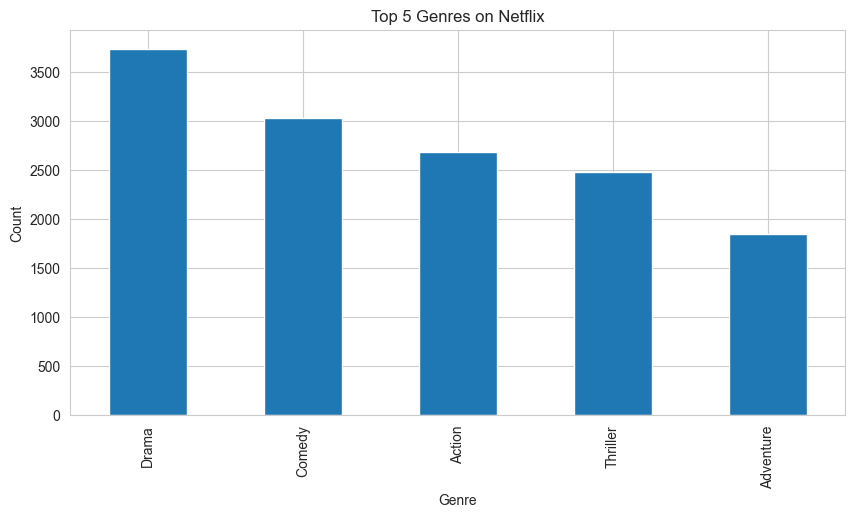

In [72]:
sns.set_style("whitegrid")
df_new['Genre'].value_counts().head().plot(kind='bar', figsize=(10,5))
plt.title('Top 5 Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.show()


As we can see, the most common genre of movies on Netflix is Drama with 3744 movies, followed by Comedy and Action.

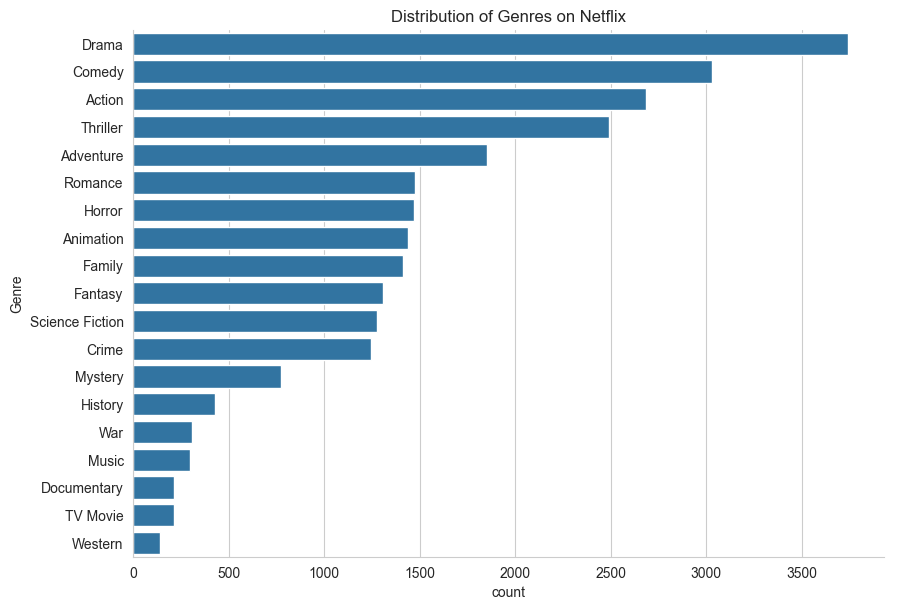

In [73]:
sns.catplot(y='Genre', data=df_new, kind='count', height=6, aspect=1.5,
            order=df_new['Genre'].value_counts().index)
plt.title('Distribution of Genres on Netflix')
plt.show()

Western, TV Movie, and Documentary are the least common genres on Netflix.

---
### Which movie has the highest average votes?

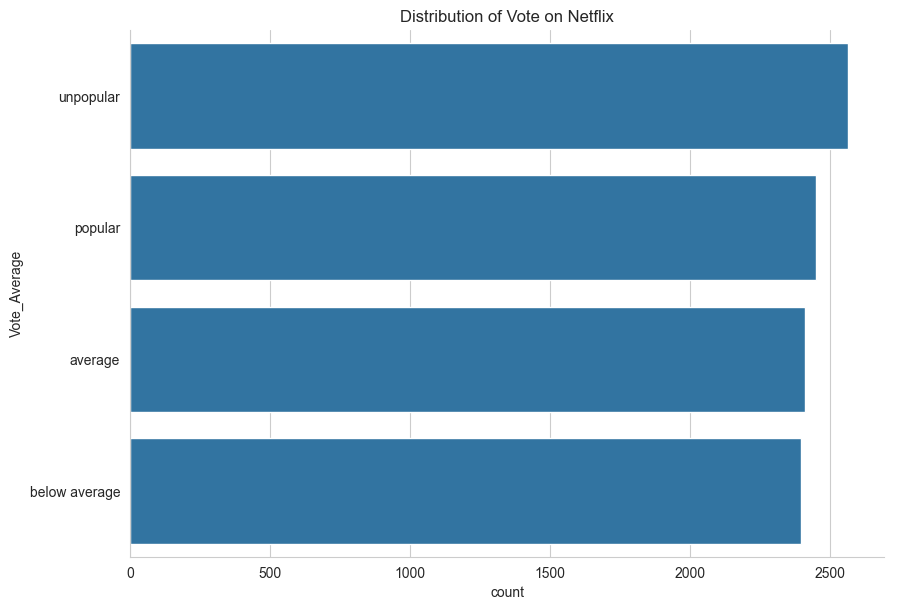

In [74]:
sns.catplot(y='Vote_Average', data=df, kind='count', height=6, aspect=1.5,
            order=df['Vote_Average'].value_counts().index)
plt.title('Distribution of Vote on Netflix')
plt.show()    

In [133]:
df_temp.groupby('Genre').Vote_Average.mean().sort_values(ascending=False).head()

Genre
History      6.965574
War          6.948701
Music        6.879322
Animation    6.846560
Western      6.754745
Name: Vote_Average, dtype: float64

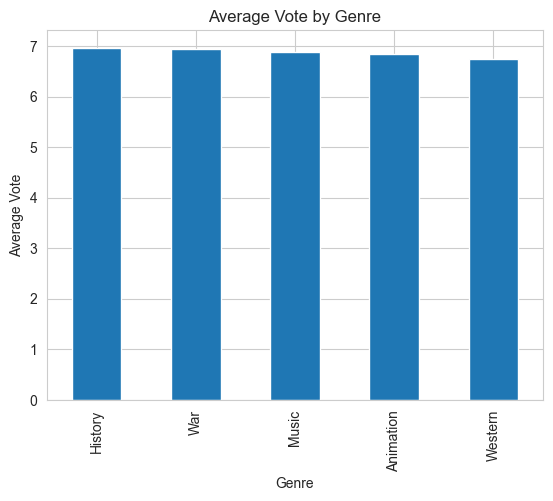

In [130]:
df_temp = pd.read_csv('netflix_movies_dataset.csv', lineterminator='\n')
df_temp['Genre'] = df_temp['Genre'].str.split(', ')
df_temp = df_temp.explode('Genre').reset_index(drop=True)
df_temp.groupby('Genre').Vote_Average.mean().sort_values(ascending=False).head().plot(kind='bar')
plt.xlabel('Genre')
plt.ylabel('Average Vote')
plt.title('Average Vote by Genre')
plt.show();

Unpopular movies based on vote average have the highest frequency on Netflix, followed by popular, average and below average movies.

History Genre has the highest average vote.

---

### Which movie got the highest popularity on Netflix and what was it genre?

In [76]:
df_new[df_new["Popularity"] == df_new["Popularity"].max()]

,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_Year
0,Spider-Man: No Way Home,5083.954,8940,popular,Action,2021
1,Spider-Man: No Way Home,5083.954,8940,popular,Adventure,2021
2,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction,2021


In [91]:
print("The movie with the highest popularity on Netflix is: ", df_new[df_new["Popularity"] == df_new["Popularity"].max()].Title.values[0], "and it's genre is", list(df_new[df_new["Popularity"] == df_new["Popularity"].max()].Genre.values[0:3]), "and it's release year is", df_new[df_new["Popularity"] == df_new["Popularity"].max()].Release_Year.values[0])

The movie with the highest popularity on Netflix is:  Spider-Man: No Way Home and it's genre is ['Action', 'Adventure', 'Science Fiction'] and it's release year is 2021


The movie with the highest popularity on Netflix is `Spider-Man: No Way Home`. It's genre is Action, Adventure, and Science Fiction. It's released in 2021

---

### Which movie has the lowest popularity on Netflix and what was it genre?

In [92]:
df_new[df_new["Popularity"] == df_new["Popularity"].min()]

,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_Year
25787,The United States vs. Billie Holiday,13.354,152,average,Music,2021
25788,The United States vs. Billie Holiday,13.354,152,average,Drama,2021
25789,The United States vs. Billie Holiday,13.354,152,average,History,2021
25790,Threads,13.354,186,popular,War,1984
25791,Threads,13.354,186,popular,Drama,1984
25792,Threads,13.354,186,popular,Science Fiction,1984


In [95]:
print("The movies with the lowest popularity on Netflix are:", list(df_new[df_new["Popularity"] == df_new["Popularity"].min()].Title.unique()))

The movies with the lowest popularity on Netflix are: ['The United States vs. Billie Holiday', 'Threads']


In [99]:
print("Genre of the movie 'The United States vs. Billie Holiday' are:", list(df_new[df_new["Title"]== 'The United States vs. Billie Holiday'].Genre.unique()))
print("The movie 'Threads' are:", list(df_new[df_new["Title"]== 'Threads'].Genre.unique()))


Genre of the movie 'The United States vs. Billie Holiday' are: ['Music', 'Drama', 'History']
The movie 'Threads' are: ['War', 'Drama', 'Science Fiction']


`'The United States vs. Billie Holiday'` and `'Threads'` are the movies with the lowest popularity on Netflix. 'United States vs. Billie Holiday' has Drama, Music, and History genre while 'Threads' has Drama, War, and Science Fiction genre.

---
### Which year has the most movies released on Netflix?

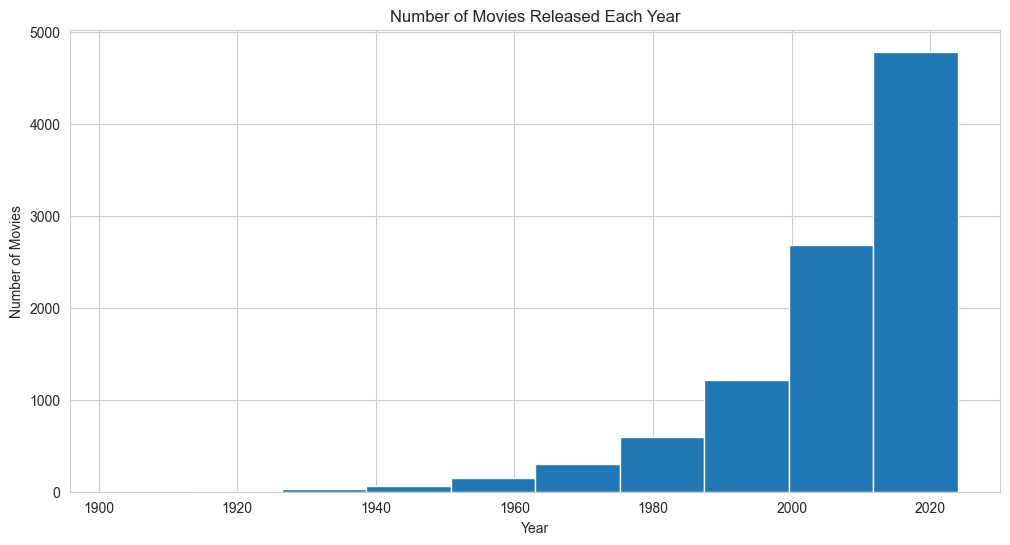

In [105]:
df['Release_Year'].plot(kind='hist', figsize=(12, 6))
plt.title('Number of Movies Released Each Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.show()

The number of movies released kept increasing over the years with highest number of movies released in 2011-2021.

In [109]:
df['Release_Year'].value_counts().head()

Release_Year
2021    714
2018    530
2017    510
2019    500
2016    470
Name: count, dtype: int64

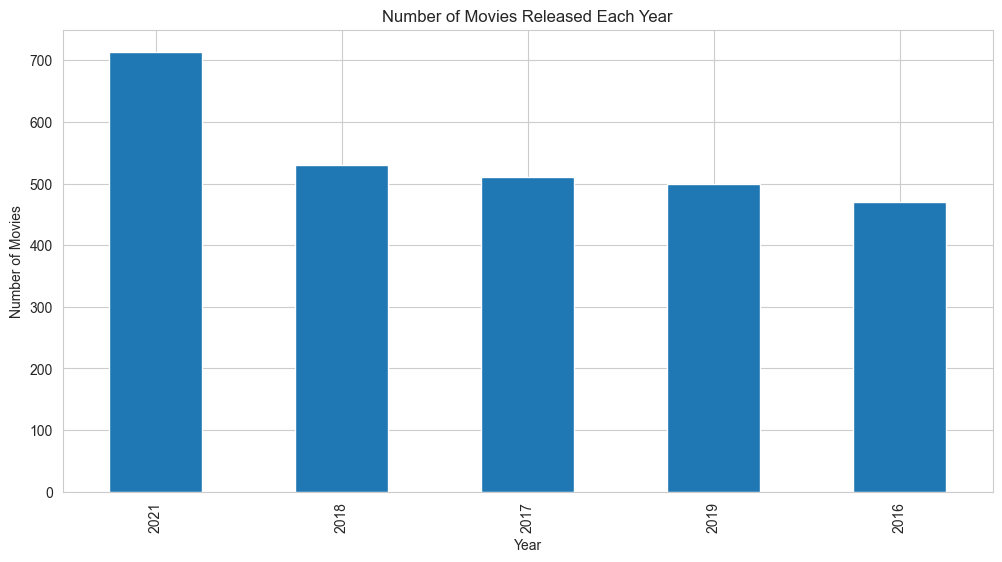

In [110]:
df['Release_Year'].value_counts().head().plot(kind='bar', figsize=(12, 6))
plt.title('Number of Movies Released Each Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.show()


Year `2021` has the highest number of movies released with 714 movies released, followed by `2018` with 530 movies released. This make sense because Corona Virus pandemic started in 2019-2020 and it affected the movie industry. Many people started streaming movies on Netflix and other streaming platforms.

---


### Summary

**Q1: What is the most common movie genre?**

Drama genre has the highest number of movies and it appeared in 3744 movies which is 38% of the total movies among 19 other genres.

**Q2: Which genre has the highest votes?**

Unpopular movies based on vote average have the highest frequency 26% on Netflix, followed by popular, average and below average. History Genre has the highest average vote of 6.97, followed by War with 6.95.

**Q3: Which movie has the highest popularity and what is it's genre?**

The movie with the highest popularity on Netflix is `Spider-Man: No Way Home`. It's genre is Action, Adventure, and Science Fiction. It's released in 2021.

**Q4: Which movie has the lowest popularity on Netflix and what was it genre?**

`'The United States vs. Billie Holiday'` and `'Threads'` are the movies with the lowest popularity on Netflix. 'United States vs. Billie Holiday' has Drama, Music, and History genre while 'Threads' has Drama, War, and Science Fiction genre.

**Q5: Which year has the most movies released on Netflix?**

2021 has the most movies released on Netflix with 714 movies released which is roughly 7% of the all movies released on Netflix since 1902 in the dataset.

---
## Author:
- [Parshv Patel](https://www.linkedin.com/in/parshv-patel-65a90326b/)